# OtoMoni モデル作成テンプレート

このノートブックでは、音響データを用いた異常検知モデル（Autoencoder）を作成します。

## 処理フロー
1. 環境設定（パッケージインストール・インポート）
2. パラメータ設定
3. モデル定義
4. データ準備
5. 特徴量抽出
6. モデル学習
7. 評価（正常・異常データ）
8. 結果可視化
9. 混同行列の計算

---
## 1. 環境設定

In [1]:
# ここではパッケージインストールは行いません（.venv311 環境にすでに導入済み）
# 必要なライブラリ（ローカル環境）
# - tensorflow==2.15.*
# - librosa==0.9.2
# - boto3
# - matplotlib
# - seaborn
# - tqdm
# - scikit-learn
# これらは C:\Users\yu_takao\Desktop\otomoni-model-master\.venv311 にインストール済みです。
# ノートブックは必ず .venv311 の Python カーネルで実行してください。

In [2]:
# ### 1.2 ライブラリインポート
import os
import sys
import math
import random
import pickle
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import boto3

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ログレベル設定
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

# カスタムツールのインポート
sys.path.append('tools')
import utils
import sound_tools_STFT

In [3]:
# ### 1.3 シード値固定（再現性確保）
def set_seed(seed=42):
    """再現性のためのシード値を固定"""
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed()

# ### 1.4 グラフ設定
%matplotlib inline
plt.style.use('Solarize_Light2')

# 日本語フォント設定（Windows環境）
import matplotlib
matplotlib.rcParams['font.family'] = 'MS Gothic'  # Windows標準の日本語フォント
matplotlib.rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化けを防ぐ

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
BLUE = colors[1]
RED = colors[5]

---
## 2. パラメータ設定

以下のパラメータで特徴抽出・モデル構築を行います。


In [4]:
# 特徴抽出パラメータ
N_MELS = 128        # メルフィルタバンクの数（メル尺度の次元数）
FRAMES = 5          # フレーム数
N_FFT = 4096        # フーリエ変換時のフレーム長
HOP_LENGTH = 256    # フーリエ変換のホップ長（ずらす長さ）
POWER = 2.0         # 振幅メルスペクトログラムの指数（1=振幅, 2=パワー）

# モデルパラメータ
INPUT_DIMS = N_MELS * FRAMES  # 入力次元数 (128 * 5 = 640)
DROPOUT_RATE = 0.0            # ドロップアウト率
LEARNING_RATE = 0.001         # 学習率
BATCH_SIZE = 20               # バッチサイズ
EPOCHS = 100                  # エポック数
VALIDATION_SPLIT = 0.2        # 検証データの割合

# ファイルパス（ローカル保存先）
DATA_DIR = 'data'
MODEL_DIR = 'saved_model'
MODEL_NAME = 'AIModelName'

# デフォルトではローカル data フォルダから読み込む
USE_S3 = False  # SageMaker などで S3 から読みたい場合だけ True にする
S3_BUCKET = 'recordings-kawasaki-city'
S3_PREFIX = 'phase1/train/'  # 末尾はスラッシュで終わるように

print(f"入力次元数: {INPUT_DIMS}")

入力次元数: 640


---
## 3. モデル定義

Autoencoderモデルを構築します。正常データのみで学習し、異常データ入力時は再構成誤差が大きくなることで異常を検知します。

In [5]:
def create_autoencoder(input_dims, dropout_rate=0.0):
    """
    Autoencoderモデルを作成
    構造: 入力 -> 64 -> 64 -> 8(潜在空間) -> 64 -> 64 -> 出力
    """
    input_layer = keras.Input(shape=(input_dims,))
    
    # エンコーダー
    h = Dense(64, activation="relu")(input_layer)
    h = Dropout(dropout_rate)(h)
    h = Dense(64, activation="relu")(h)
    h = Dropout(dropout_rate)(h)
    h = Dense(8, activation="relu")(h)  # 潜在空間
    h = Dropout(dropout_rate)(h)
    
    # デコーダー
    h = Dense(64, activation="relu")(h)
    h = Dropout(dropout_rate)(h)
    h = Dense(64, activation="relu")(h)
    h = Dropout(dropout_rate)(h)
    output_layer = Dense(input_dims, activation=None)(h)
    
    return Model(inputs=input_layer, outputs=output_layer)

# モデル作成
model = create_autoencoder(INPUT_DIMS, DROPOUT_RATE)
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 640)]             0         
                                                                 
 dense (Dense)               (None, 64)                41024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 8)                 520       
                                                                 
 dropout_2 (Dropout)         (None, 8)                 0    

In [6]:
# モデルコンパイル
model.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

In [7]:
# 初期重みを保存（必要に応じて）
os.makedirs(MODEL_DIR, exist_ok=True)
model.save_weights(f'{MODEL_DIR}/saved_model.weights.h5')
model.save(f'{MODEL_DIR}/test-model-on-notebook.keras')
print(f"初期モデルを保存しました: {MODEL_DIR}/")

初期モデルを保存しました: saved_model/


In [8]:
# ---
# ## 4. データ準備

# 音データの取得
from glob import glob  # 念のためこのセル内でも glob を定義しておく
# USE_S3 が未定義でもエラーにならないようにデフォルト値を設定
use_s3 = globals().get('USE_S3', False)

if use_s3:
    # S3 上の WAV ファイル一覧を取得
    s3 = boto3.client('s3')

    def list_s3_wavs(bucket, prefix):
        files = []
        continuation_token = None
        while True:
            kwargs = {'Bucket': bucket, 'Prefix': prefix}
            if continuation_token:
                kwargs['ContinuationToken'] = continuation_token
            resp = s3.list_objects_v2(**kwargs)
            for obj in resp.get('Contents', []):
                key = obj['Key']
                if key.lower().endswith('.wav'):
                    files.append(f's3://{bucket}/{key}')
            if not resp.get('IsTruncated'):
                break
            continuation_token = resp.get('NextContinuationToken')
        return files

    normal_files = list_s3_wavs(S3_BUCKET, S3_PREFIX)
    # 異常データは今回なし（将来用に変数だけ残しておく）
    abnormal_files = []
else:
    # ローカル data 配下の WAV を使用する場合
    normal_files = glob(os.path.join(DATA_DIR, "*.wav"))
    abnormal_files = []

print(f"正常データ数: {len(normal_files)}")
print(f"異常データ数: {len(abnormal_files)}")

# 訓練・テストデータの分割
X = np.array(normal_files)
y = np.zeros(len(normal_files))

train_files, test_files, train_labels, test_labels = train_test_split(
    X, y,
    train_size=0.9,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"\n訓練データ数: {len(train_files)}")
print(f"テストデータ数（正常）: {len(test_files)}")
print(f"テストデータ数（異常）: {len(abnormal_files)}")

# データセット情報をCSVに保存
dataset = {
    'train_files': train_files,
    'test_files': test_files,
    'abnormal_test': abnormal_files,
}

dataset_csv_dir = os.path.join(DATA_DIR, 'dataset_csv')
os.makedirs(dataset_csv_dir, exist_ok=True)

for key, values in dataset.items():
    fname = os.path.join(dataset_csv_dir, f'{key}.txt')
    with open(fname, 'w') as f:
        for item in values:
            f.write(f"{item}\n")
    print(f"{key}: {len(values)} files -> {fname}")

正常データ数: 1000
異常データ数: 0

訓練データ数: 900
テストデータ数（正常）: 100
テストデータ数（異常）: 0
train_files: 900 files -> data\dataset_csv\train_files.txt
test_files: 100 files -> data\dataset_csv\test_files.txt
abnormal_test: 0 files -> data\dataset_csv\abnormal_test.txt


---
## 5. 特徴量抽出

In [9]:
train_data_path = os.path.join(DATA_DIR, 'train_data-STFT.pkl')

if os.path.exists(train_data_path):
    print('訓練データが既に存在します。ファイルから読み込み中...')
    with open(train_data_path, 'rb') as f:
        train_data = pickle.load(f)
else:
    print('特徴量を抽出中...')
    os.makedirs(DATA_DIR, exist_ok=True)
    train_data = sound_tools_STFT.generate_dataset(
        train_files, 
        n_mels=N_MELS, 
        frames=FRAMES, 
        n_fft=N_FFT, 
        hop_length=HOP_LENGTH
    )
    print('訓練データを保存中...')
    with open(train_data_path, 'wb') as f:
        pickle.dump(train_data, f)
    print('完了')

print(f"訓練データ形状: {train_data.shape}")

特徴量を抽出中...


Extracting features: 100%|██████████| 900/900 [03:10<00:00,  4.71it/s]


訓練データを保存中...
完了
訓練データ形状: (772200, 640)


---
## 6. モデル学習

In [10]:
history = model.fit(
    train_data,
    train_data,  # Autoencoderは入力=出力
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    shuffle=True,
    verbose=2
)

Epoch 1/100


30888/30888 - 44s - loss: 3.4193 - accuracy: 0.2529 - val_loss: 2.6858 - val_accuracy: 0.2954 - 44s/epoch - 1ms/step
Epoch 2/100
30888/30888 - 44s - loss: 2.6545 - accuracy: 0.2489 - val_loss: 2.6927 - val_accuracy: 0.2232 - 44s/epoch - 1ms/step
Epoch 3/100
30888/30888 - 44s - loss: 2.6256 - accuracy: 0.2389 - val_loss: 2.5853 - val_accuracy: 0.2350 - 44s/epoch - 1ms/step
Epoch 4/100
30888/30888 - 43s - loss: 2.5821 - accuracy: 0.2291 - val_loss: 2.5599 - val_accuracy: 0.1559 - 43s/epoch - 1ms/step
Epoch 5/100
30888/30888 - 43s - loss: 2.5610 - accuracy: 0.2287 - val_loss: 2.5519 - val_accuracy: 0.2121 - 43s/epoch - 1ms/step
Epoch 6/100
30888/30888 - 43s - loss: 2.5520 - accuracy: 0.2253 - val_loss: 2.5632 - val_accuracy: 0.1925 - 43s/epoch - 1ms/step
Epoch 7/100
30888/30888 - 44s - loss: 2.5512 - accuracy: 0.2234 - val_loss: 2.5454 - val_accuracy: 0.1868 - 44s/epoch - 1ms/step
Epoch 8/100
30888/30888 - 46s - loss: 2.5456 - accuracy: 0.2232 - val_loss: 2.5768 - val_accura

In [11]:
# 学習済みモデルの保存
model_path = f'{MODEL_DIR}/{MODEL_NAME}.keras'
model.save(model_path)
print(f"モデルを保存しました: {model_path}")

モデルを保存しました: saved_model/AIModelName.keras


In [12]:
# モデルの読み込み（確認用）
loaded_model = tf.keras.models.load_model(model_path)
print(f"モデルを読み込みました: {model_path}")

モデルを読み込みました: saved_model/AIModelName.keras


---
## 7. 評価

In [13]:
# ### 7.1 評価関数の定義
def evaluate_files(file_list, model, n_mels, frames, n_fft, hop_length):
    """ファイルリストに対して再構成誤差を計算"""
    reconstruction_errors = []
    
    for eval_filename in tqdm(file_list, desc='評価中'):
        # 音声ファイル読み込み
        signal, sr = sound_tools_STFT.load_sound_file(eval_filename)
        
        # 特徴量抽出
        eval_features = sound_tools_STFT.extract_signal_features(
            signal, sr, 
            n_mels=n_mels, 
            frames=frames, 
            n_fft=n_fft, 
            hop_length=hop_length
        )
        
        # Autoencoderで予測
        prediction = model.predict(eval_features, verbose=0)
        
        # 再構成誤差（MSE）を計算
        mse = np.mean(np.mean(np.square(eval_features - prediction), axis=1))
        reconstruction_errors.append(mse)
    
    return reconstruction_errors

In [14]:
# ### 7.2 正常データの評価
normal_reconstruction_errors = evaluate_files(
    test_files, model, N_MELS, FRAMES, N_FFT, HOP_LENGTH
)

# 結果をDataFrameに保存
df_normal = pd.DataFrame({
    'FileName': test_files,
    'Reconstruction Error': normal_reconstruction_errors
})
df_normal.to_csv(os.path.join(DATA_DIR, 'prediction-sftt-preprocess-model-normal.csv'), index=False)
print(df_normal)

評価中: 100%|██████████| 100/100 [00:32<00:00,  3.12it/s]

                      FileName  Reconstruction Error
0   data\rec-1760336113583.wav              2.764701
1   data\rec-1760131356916.wav              2.414366
2   data\rec-1760592609529.wav              2.686960
3   data\rec-1760401543143.wav              2.337728
4   data\rec-1760284201200.wav              2.417710
..                         ...                   ...
95  data\rec-1759956692975.wav              2.980382
96  data\rec-1759913610825.wav              2.603332
97  data\rec-1760978890848.wav              2.548538
98  data\rec-1760127752331.wav              2.460137
99  data\rec-1760616044725.wav              2.538002

[100 rows x 2 columns]


In [15]:
# ### 7.3 異常データの評価
abnormal_reconstruction_errors = evaluate_files(
    abnormal_files, model, N_MELS, FRAMES, N_FFT, HOP_LENGTH
)

# 結果をDataFrameに保存
df_abnormal = pd.DataFrame({
    'FileName': abnormal_files,
    'Reconstruction Error': abnormal_reconstruction_errors
})
df_abnormal.to_csv(os.path.join(DATA_DIR, 'prediction-sftt-preprocess-model-abnormal.csv'), index=False)
print(df_abnormal)

評価中: 0it [00:00, ?it/s]

Empty DataFrame
Columns: [FileName, Reconstruction Error]
Index: []


---
## 8. 結果可視化

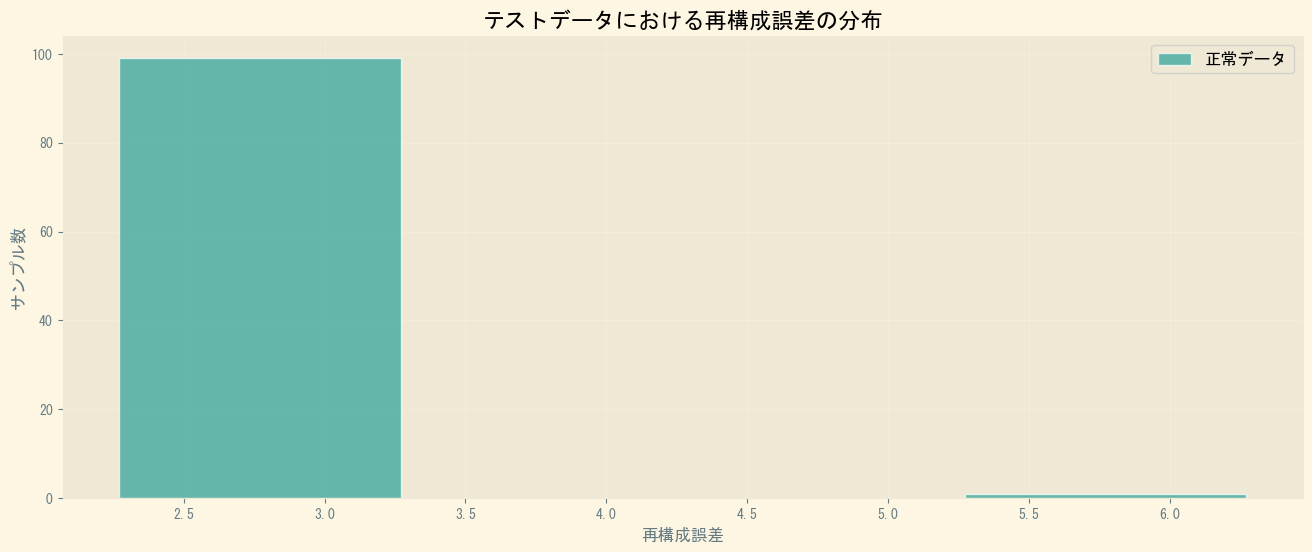


正常データ再構成誤差: 平均=2.5731, 標準偏差=0.3901
異常データが無いため、異常側の統計値は計算していません。


In [16]:
# ヒストグラムで再構成誤差の分布を可視化
normal_data = np.column_stack((range(len(normal_reconstruction_errors)), normal_reconstruction_errors))

bin_width = 1
bins_normal = np.arange(
    min(normal_reconstruction_errors), 
    int(max(normal_reconstruction_errors)) + bin_width, 
    bin_width
)

fig = plt.figure(figsize=(16, 6))

# 異常データが存在する場合のみ重ねて表示
if len(abnormal_reconstruction_errors) > 0:
    anomaly_data = np.column_stack((range(len(abnormal_reconstruction_errors)), abnormal_reconstruction_errors))
    bins_abnormal = np.arange(
        min(abnormal_reconstruction_errors), 
        int(max(abnormal_reconstruction_errors)) + bin_width, 
        bin_width
    )
    plt.hist(anomaly_data[:, 1], bins=bins_abnormal, color=RED, alpha=0.7, 
             label='異常データ', edgecolor='#FFFFFF')

plt.hist(normal_data[:, 1], bins=bins_normal, color=BLUE, alpha=0.7, 
         label='正常データ', edgecolor='#FFFFFF')

plt.xlabel("再構成誤差", fontsize=12)
plt.ylabel("サンプル数", fontsize=12)
plt.title('テストデータにおける再構成誤差の分布', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig(os.path.join(DATA_DIR, 'prediction-stft-picture.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n正常データ再構成誤差: 平均={np.mean(normal_reconstruction_errors):.4f}, 標準偏差={np.std(normal_reconstruction_errors):.4f}")
if len(abnormal_reconstruction_errors) > 0:
    print(f"異常データ再構成誤差: 平均={np.mean(abnormal_reconstruction_errors):.4f}, 標準偏差={np.std(abnormal_reconstruction_errors):.4f}")
else:
    print("異常データが無いため、異常側の統計値は計算していません。")

---
## 9. 混同行列の計算

In [17]:
# CSVファイルを読み込んでラベル付け
df_normal_pred = pd.read_csv(os.path.join(DATA_DIR, 'prediction-sftt-preprocess-model-normal.csv'))
df_normal_pred['label'] = 'normal'

df_abnormal_pred = pd.read_csv(os.path.join(DATA_DIR, 'prediction-sftt-preprocess-model-abnormal.csv'))
df_abnormal_pred['label'] = 'abnormal'

# データを結合
df_prediction = pd.concat([df_normal_pred, df_abnormal_pred], ignore_index=True)
print(f"全データ数: {len(df_prediction)}")
print(df_prediction)

全データ数: 100
                      FileName  Reconstruction Error   label
0   data\rec-1760336113583.wav              2.764701  normal
1   data\rec-1760131356916.wav              2.414366  normal
2   data\rec-1760592609529.wav              2.686961  normal
3   data\rec-1760401543143.wav              2.337728  normal
4   data\rec-1760284201200.wav              2.417710  normal
..                         ...                   ...     ...
95  data\rec-1759956692975.wav              2.980382  normal
96  data\rec-1759913610825.wav              2.603332  normal
97  data\rec-1760978890848.wav              2.548538  normal
98  data\rec-1760127752331.wav              2.460137  normal
99  data\rec-1760616044725.wav              2.538002  normal

[100 rows x 3 columns]


C:\Users\yu_takao\AppData\Local\Temp\ipykernel_29480\2144035806.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_prediction = pd.concat([df_normal_pred, df_abnormal_pred], ignore_index=True)


In [18]:
# 閾値の範囲を設定
max_error = math.ceil(df_prediction['Reconstruction Error'].max())
min_error = math.floor(df_prediction['Reconstruction Error'].min())
print(f"再構成誤差の範囲: {min_error} ~ {max_error}")

# 各閾値での混同行列を計算
results = []

for threshold in range(min_error, max_error + 1):
    TP = TN = FN = FP = 0
    
    for _, row in df_prediction.iterrows():
        is_normal = row["label"] == "normal"
        is_below_threshold = row["Reconstruction Error"] < threshold
        
        if is_normal and is_below_threshold:
            TP += 1  # 正常を正常と判定
        elif is_normal and not is_below_threshold:
            FN += 1  # 正常を異常と判定
        elif not is_normal and is_below_threshold:
            FP += 1  # 異常を正常と判定
        else:
            TN += 1  # 異常を異常と判定
    
    # 評価指標の計算
    total = len(df_prediction)
    accuracy = ((TP + TN) / total) * 100
    recall = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0
    precision = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 100
    f1 = 2 * (recall * precision) / (recall + precision) if (recall + precision) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN,
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision,
        'F1': f1
    })

df_confusion = pd.DataFrame(results)
df_confusion.to_csv(os.path.join(DATA_DIR, 'df_confusion_matrix.csv'), index=False)
print(df_confusion)

再構成誤差の範囲: 2 ~ 7
   threshold   TP   FN  FP  TN  accuracy  recall  precision          F1
0          2    0  100   0   0       0.0     0.0      100.0    0.000000
1          3   97    3   0   0      97.0    97.0      100.0   98.477157
2          4   99    1   0   0      99.0    99.0      100.0   99.497487
3          5   99    1   0   0      99.0    99.0      100.0   99.497487
4          6   99    1   0   0      99.0    99.0      100.0   99.497487
5          7  100    0   0   0     100.0   100.0      100.0  100.000000


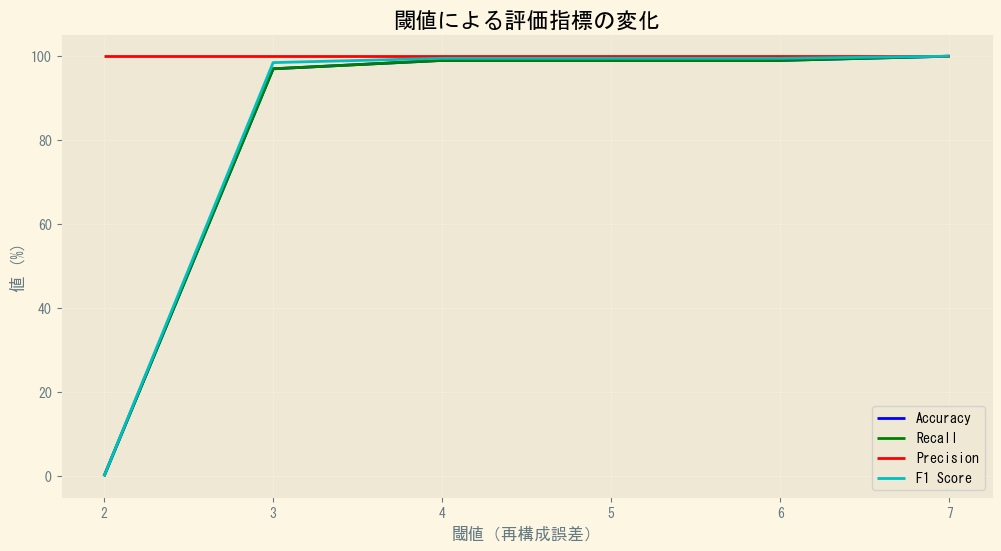


最適な閾値（F1スコア最大）: 7
threshold      7.0
TP           100.0
FN             0.0
FP             0.0
TN             0.0
accuracy     100.0
recall       100.0
precision    100.0
F1           100.0
Name: 5, dtype: float64


In [19]:
# 混同行列の指標をグラフで表示
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_confusion['threshold'], df_confusion['accuracy'], 
        label='Accuracy', color='b', linewidth=2)
ax.plot(df_confusion['threshold'], df_confusion['recall'], 
        label='Recall', color='g', linewidth=2)
ax.plot(df_confusion['threshold'], df_confusion['precision'], 
        label='Precision', color='r', linewidth=2)
ax.plot(df_confusion['threshold'], df_confusion['F1'], 
        label='F1 Score', color='c', linewidth=2)

ax.set_title('閾値による評価指標の変化', fontsize=16)
ax.set_xlabel('閾値（再構成誤差）', fontsize=12)
ax.set_ylabel('値 (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(DATA_DIR, 'confusion-matrix-picture.png'), dpi=150, bbox_inches='tight')
plt.show()

# 最適な閾値を表示
best_f1_idx = df_confusion['F1'].idxmax()
best_threshold = df_confusion.loc[best_f1_idx, 'threshold']
print(f"\n最適な閾値（F1スコア最大）: {best_threshold}")
print(df_confusion.loc[best_f1_idx])

---
## 10. NG フォルダの異音データを判定

学習済みモデルを使って、`NG` フォルダ内の異音データを判定します。  
再構成誤差が閾値より高ければ「**異常（NG）**」と判定します。


In [23]:
# NG フォルダ内の異音データを取得
NG_DIR = 'NG'
ng_files = glob(os.path.join(NG_DIR, '*.wav'))
print(f"NG フォルダ内のファイル数: {len(ng_files)}")
for f in ng_files:
    print(f"  - {f}")


NG フォルダ内のファイル数: 2
  - NG\NG1.wav
  - NG\NG2.wav


In [24]:
# 閾値を設定（正常データの平均 + 2σ を使用）
normal_mean = np.mean(normal_reconstruction_errors)
normal_std = np.std(normal_reconstruction_errors)
THRESHOLD = normal_mean + 2 * normal_std

print(f"正常データ再構成誤差: 平均={normal_mean:.4f}, 標準偏差={normal_std:.4f}")
print(f"判定閾値（平均 + 2σ）: {THRESHOLD:.4f}")
print("-" * 50)


正常データ再構成誤差: 平均=2.5731, 標準偏差=0.3901
判定閾値（平均 + 2σ）: 3.3534
--------------------------------------------------


In [25]:
# NG フォルダのデータを評価
if len(ng_files) > 0:
    ng_reconstruction_errors = evaluate_files(
        ng_files, model, N_MELS, FRAMES, N_FFT, HOP_LENGTH
    )
    
    # 結果を表示
    print("\n" + "=" * 60)
    print("【異音判定結果】")
    print("=" * 60)
    
    for filename, error in zip(ng_files, ng_reconstruction_errors):
        is_anomaly = error > THRESHOLD
        result = "🔴 異常（NG）" if is_anomaly else "🟢 正常（OK）"
        print(f"\nファイル: {os.path.basename(filename)}")
        print(f"  再構成誤差: {error:.4f}")
        print(f"  閾値: {THRESHOLD:.4f}")
        print(f"  判定結果: {result}")
    
    # 統計サマリ
    print("\n" + "-" * 60)
    print("【サマリ】")
    print(f"  テストファイル数: {len(ng_files)}")
    print(f"  異常と判定された数: {sum(1 for e in ng_reconstruction_errors if e > THRESHOLD)}")
    print(f"  正常と判定された数: {sum(1 for e in ng_reconstruction_errors if e <= THRESHOLD)}")
else:
    print("NG フォルダに WAV ファイルがありません。")


評価中: 100%|██████████| 2/2 [00:00<00:00,  3.76it/s]


【異音判定結果】

ファイル: NG1.wav
  再構成誤差: 7.5986
  閾値: 3.3534
  判定結果: 🔴 異常（NG）

ファイル: NG2.wav
  再構成誤差: 5.8886
  閾値: 3.3534
  判定結果: 🔴 異常（NG）

------------------------------------------------------------
【サマリ】
  テストファイル数: 2
  異常と判定された数: 2
  正常と判定された数: 0
